In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D

plt.rc('axes', linewidth=3, labelsize=20)
plt.rc('xtick', labelsize=20)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=20)  # fontsize of the y tick labels

sns.set_context("talk")
sns.set(font_scale=1.5)
sns.set_style("white")

%matplotlib inline

In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

In [3]:
results_directory={"../result/gromacs/bulk/alpha_quartz/result/md_prod_100/":("PoreMS",100,"α-quartz")
                   ,"../result/gromacs/bulk/alpha_quartz/result/md_prod_200/":("PoreMS",200,"α-quartz")
                   ,"../result/gromacs/bulk/alpha_quartz/result/md_prod_300/":("PoreMS",300,"α-quartz")
                   , "../result/gromacs/bulk/amorphous/result/md_prod_100/":("PoreMS",100,"Amorphous")
                   ,"../result/gromacs/bulk/amorphous/result/md_prod_200/":("PoreMS",200,"Amorphous")
                   ,"../result/gromacs/bulk/amorphous/result/md_prod_300/":("PoreMS",300,"Amorphous")
                                      
                  }
df_list=list()

min_energy=0
max_energy=150

for data_directory,(force_field,temperature,sys) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array

        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Weight"]=" ".join(filename.split("_")[:-1]).replace('b ','').capitalize()
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
        for species in ["Si","O"]:
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species)
            df_tmp[species]/=df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
                
        df_tmp["Temperature (K)"]=temperature
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
        
df_dos_gromacs=pd.concat(df_list,ignore_index=True)

../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/alpha_quartz/result/md_prod_300/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/amorphous/result/md_prod_300/b_incoherent_dos.h5


In [4]:
df_dos_gromacs

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Weight,Method,System,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Temperature (K),Software
0,-2.047247e-06,-5.463273e-07,-1.651980e-06,0.125676,0.0,1.0,Coherent,MD,α-quartz,PoreMS,0.082720,-0.001039,-0.006381,-0.018530,-0.017755,-1.166913,100,gromacs
1,2.749994e-06,1.086007e-06,2.311784e-06,0.251353,0.0,1.0,Coherent,MD,α-quartz,PoreMS,0.165440,0.000363,0.003171,0.006223,0.006212,0.204122,100,gromacs
2,2.073332e-06,2.529622e-06,2.193496e-06,0.377029,0.0,1.0,Coherent,MD,α-quartz,PoreMS,0.248160,0.000690,0.014773,0.009383,0.011787,0.258237,100,gromacs
3,3.925980e-06,2.098242e-06,3.444646e-06,0.502705,0.0,1.0,Coherent,MD,α-quartz,PoreMS,0.330881,0.000542,0.006127,0.008884,0.009255,0.152075,100,gromacs
4,7.639660e-07,1.465393e-06,9.486865e-07,0.628381,0.0,1.0,Coherent,MD,α-quartz,PoreMS,0.413601,0.000298,0.008558,0.003457,0.005098,0.067013,100,gromacs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21751,4.359395e-06,1.768909e-06,2.993558e-06,227.348384,0.0,1.0,Incoherent,MD,Amorphous,PoreMS,149.640707,0.000227,0.003429,0.005947,0.004927,0.000219,300,gromacs
21752,3.371505e-06,1.393352e-06,2.328522e-06,227.474061,0.0,1.0,Incoherent,MD,Amorphous,PoreMS,149.723427,0.000226,0.003410,0.005913,0.004899,0.000217,300,gromacs
21753,4.456556e-06,1.787289e-06,3.049182e-06,227.599737,0.0,1.0,Incoherent,MD,Amorphous,PoreMS,149.806147,0.000224,0.003391,0.005878,0.004871,0.000216,300,gromacs
21754,3.484632e-06,1.417668e-06,2.394823e-06,227.725413,0.0,1.0,Incoherent,MD,Amorphous,PoreMS,149.888867,0.000223,0.003372,0.005844,0.004843,0.000215,300,gromacs


In [9]:
results_directory={"../result/lammps/bulk/alpha_quartz/vashishta/result/mdanse/":("VFF1990","α-quartz" )
                   ,"../result/lammps/bulk/alpha_quartz/reaxff2023/result/mdanse/":("ReaxFF2023","α-quartz")
                   ,"../result/lammps/bulk/amorphous/vashishta/result/mdanse/":("VFF1990","Amorphous" )
                   ,"../result/lammps/bulk/amorphous/reaxff2023/result/mdanse/":("ReaxFF2023","Amorphous")
                  }
df_list=list()

min_energy=0
max_energy=150

for data_directory,(force_field,sys) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Temperature (K)"]=int(filename.split("_")[2].replace('K',''))
        df_tmp["Weight"]=" ".join(filename.split("_")[:-2]).replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=9)
        for species,unit_cell_atoms in {"Si":3,"O":6}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp[species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)



../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/b_incoherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse

In [10]:
df_dos_md=pd.concat([df_dos_lammps,df_dos_gromacs])
df_dos_md

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,System,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software
0,-0.000001,-5.677117e-07,-0.000001,0.062838,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,0.041360,-0.012014,-0.011167,-0.017699,-0.016504,-5.920716,lammps
1,0.000002,6.121185e-07,0.000001,0.125676,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,0.082720,0.003174,0.003010,0.004663,0.004361,0.782151,lammps
2,-0.000001,-5.677220e-07,-0.000001,0.188514,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,0.124080,-0.006007,-0.005584,-0.008850,-0.008253,-0.986861,lammps
3,0.000002,6.120368e-07,0.000001,0.251353,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,0.165440,0.003174,0.003010,0.004663,0.004361,0.391103,lammps
4,-0.000001,-5.674285e-07,-0.000001,0.314191,0.0,1.0,100,Coherent,MD,α-quartz,VFF1990,0.206800,-0.006006,-0.005581,-0.008849,-0.008251,-0.592018,lammps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21751,0.000004,1.768909e-06,0.000003,227.348384,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,149.640707,0.000227,0.003429,0.005947,0.004927,0.000219,gromacs
21752,0.000003,1.393352e-06,0.000002,227.474061,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,149.723427,0.000226,0.003410,0.005913,0.004899,0.000217,gromacs
21753,0.000004,1.787289e-06,0.000003,227.599737,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,149.806147,0.000224,0.003391,0.005878,0.004871,0.000216,gromacs
21754,0.000003,1.417668e-06,0.000002,227.725413,0.0,1.0,300,Incoherent,MD,Amorphous,PoreMS,149.888867,0.000223,0.003372,0.005844,0.004843,0.000215,gromacs


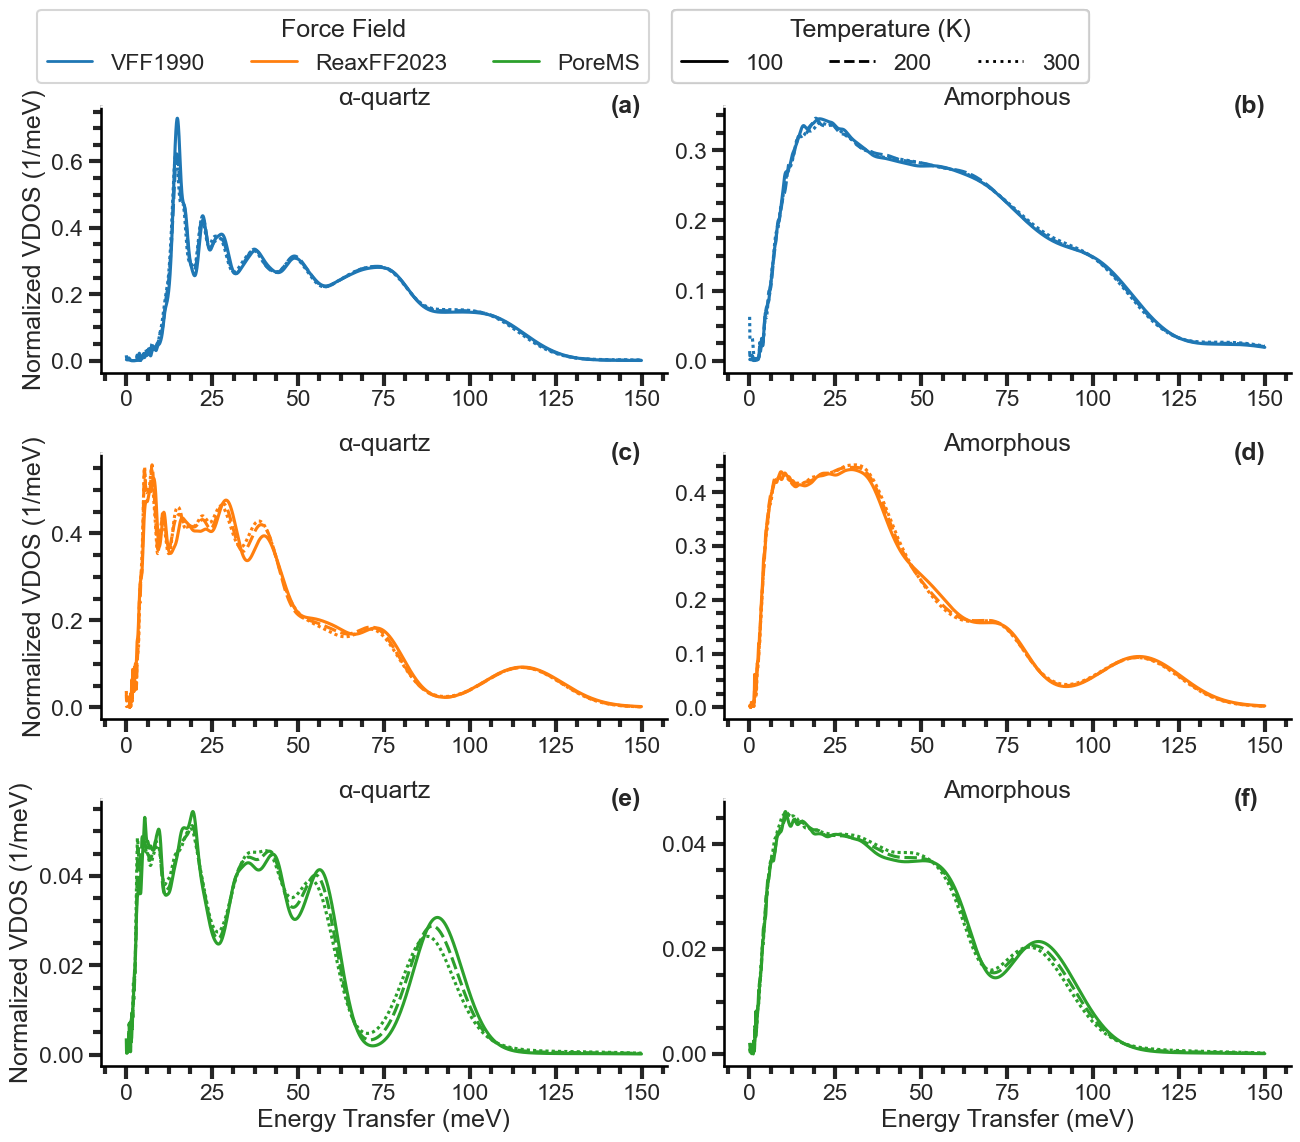

In [11]:
fig, axs = plt.subplots(ncols=2,nrows=3,figsize=(7*2,4*3))
sns.set_context("talk")
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
index=["(%s)"%x for x in list("abcdef")]

force_fields=df_dos_md["Force Field"].unique()
for i, sys in enumerate(df_dos_md["System"].unique()):
    for j,force_field in enumerate(force_fields):
        ax=axs[j,i]
        ax.text(labx, laby, index[2*j+i],weight='bold' ,transform=ax.transAxes)

        sns.lineplot(data=df_dos_md.query("Weight== 'Incoherent' and System == '%s' and `S(E)` > 0 and `Force Field` == '%s'"%(sys,force_field))
                    ,y="Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                    ,style="Temperature (K)"
                   ,color=palette[j]
                    ,legend=False
               )

        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(which='both',direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.set_ylabel("Normalized VDOS (1/meV)")

        if j < len(force_fields)-1:
            ax.set_xlabel("")
        if i >0:
            ax.set_ylabel("")
            
        ax.set_title(sys,y=0.975)
            
        if i*j ==0:
            custom_lines = [Line2D([0], [0], color="black", lw=2)
                            ,Line2D([0], [0], color="black", lw=2,ls="dashed")
                            ,Line2D([0], [0], color="black", lw=2,ls="dotted")
                           ]
            ax.legend(custom_lines,list(df_dos_md["Temperature (K)"].unique()),title="Temperature (K)")
            sns.move_legend(ax,'center left',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)

        ax.minorticks_on()
        ax.xaxis.set_minor_locator(MultipleLocator(25/4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
            
custom_lines = [Line2D([0], [0], color=palette[0], lw=2)
                ,Line2D([0], [0], color=palette[1], lw=2)
                ,Line2D([0], [0], color=palette[2], lw=2)
               ]
ax.legend(custom_lines,list(force_fields),title="Force Field")
sns.move_legend(ax,'center right',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)


            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.1, 
                    hspace=0.3
                   )

plt.savefig("../figures/fig5.pdf", pad_inches=0.2,bbox_inches="tight")